In [1]:
!pip install numpy pandas matplotlib seaborn scikit-learn

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve
)

%matplotlib inline
sns.set_style("whitegrid")
sns.set_palette("husl")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("All imports successful!")

All imports successful!


In [3]:
print("="*70)
print("CREDIT SCORING DATASET GENERATION")
print("="*70)

def generate_credit_dataset(n_samples=10000):
    """Generate synthetic credit scoring dataset"""
    np.random.seed(RANDOM_STATE)
    
    # Create features
    data = pd.DataFrame({
        'age': np.random.randint(18, 70, n_samples),
        'annual_income': np.random.randint(20000, 150000, n_samples),
        'monthly_income': np.random.randint(1500, 12000, n_samples),
        'total_debt': np.random.randint(0, 80000, n_samples),
        'credit_card_debt': np.random.randint(0, 30000, n_samples),
        'loan_debt': np.random.randint(0, 50000, n_samples),
        'payment_history': np.random.randint(0, 100, n_samples),
        'credit_history_length': np.random.randint(0, 30, n_samples),
        'num_credit_cards': np.random.randint(0, 10, n_samples),
        'late_payments': np.random.randint(0, 20, n_samples),
        'defaulted_past': np.random.choice([0, 1], n_samples, p=[0.9, 0.1]),
        'employment_status': np.random.choice(['Employed', 'Self-Employed', 'Unemployed'], 
                                              n_samples, p=[0.6, 0.25, 0.15]),
        'home_ownership': np.random.choice(['Own', 'Rent', 'Mortgage'], 
                                          n_samples, p=[0.3, 0.3, 0.4])
    })
    
    # Feature Engineering - Create derived features
    data['debt_to_income_ratio'] = data['total_debt'] / (data['annual_income'] + 1)
    data['credit_utilization'] = data['credit_card_debt'] / (data['total_debt'] + 1)
    data['payment_reliability'] = data['payment_history'] / 100
    data['late_payment_rate'] = data['late_payments'] / (data['num_credit_cards'] + 1)
    
    # Calculate credit score (target)
    credit_score = (
        (data['annual_income'] / 100000) * 15 +
        (data['debt_to_income_ratio'] < 0.3).astype(int) * 20 +
        (data['credit_utilization'] < 0.3).astype(int) * 15 +
        data['payment_reliability'] * 20 +
        (data['credit_history_length'] / 30) * 10 +
        (data['late_payments'] < 3).astype(int) * 10 +
        (data['defaulted_past'] == 0).astype(int) * 10 -
        (data['late_payments'] * 2)
    )
    
    # Add some noise
    credit_score += np.random.normal(0, 5, n_samples)
    credit_score = credit_score.clip(0, 100)
    
    # Create target (0 = Bad Credit, 1 = Good Credit)
    data['credit_risk'] = (credit_score > 60).astype(int)
    
    # Handle missing values (add some)
    for col in data.select_dtypes(include=[np.number]).columns:
        if col != 'credit_risk':
            missing_mask = np.random.random(n_samples) < 0.02
            data.loc[missing_mask, col] = np.nan
    
    return data

# Generate dataset
print("Generating credit scoring dataset...")
df = generate_credit_dataset(n_samples=10000)
print(f"Dataset shape: {df.shape}")
print(f"Features: {df.columns.tolist()}")
print(f"\nTarget Distribution:")
print(df['credit_risk'].value_counts())
print(f"Good Credit: {df['credit_risk'].value_counts(normalize=True)[1]*100:.2f}%")
print(f"Bad Credit: {df['credit_risk'].value_counts(normalize=True)[0]*100:.2f}%")
print("\nFirst 5 rows:")
df.head()

CREDIT SCORING DATASET GENERATION
Generating credit scoring dataset...
Dataset shape: (10000, 18)
Features: ['age', 'annual_income', 'monthly_income', 'total_debt', 'credit_card_debt', 'loan_debt', 'payment_history', 'credit_history_length', 'num_credit_cards', 'late_payments', 'defaulted_past', 'employment_status', 'home_ownership', 'debt_to_income_ratio', 'credit_utilization', 'payment_reliability', 'late_payment_rate', 'credit_risk']

Target Distribution:
credit_risk
0    9054
1     946
Name: count, dtype: int64
Good Credit: 9.46%
Bad Credit: 90.54%

First 5 rows:


,age,annual_income,monthly_income,total_debt,credit_card_debt,loan_debt,payment_history,credit_history_length,num_credit_cards,late_payments,defaulted_past,employment_status,home_ownership,debt_to_income_ratio,credit_utilization,payment_reliability,late_payment_rate,credit_risk
0,56.0,29930.0,9207.0,50637.0,13172.0,47055.0,11.0,24.0,3.0,4.0,0.0,Self-Employed,Mortgage,1.691791,0.260121,0.11,1.000000,0
1,69.0,23285.0,2011.0,22129.0,1465.0,937.0,22.0,12.0,2.0,16.0,0.0,Employed,Mortgage,0.950313,0.066200,0.22,5.333333,0
2,46.0,143637.0,6582.0,30845.0,18535.0,NaN,15.0,5.0,3.0,12.0,0.0,Employed,Mortgage,0.214741,0.600888,0.15,3.000000,0
3,32.0,55863.0,8360.0,79449.0,3483.0,17673.0,43.0,24.0,3.0,5.0,NaN,Unemployed,Mortgage,1.422186,0.043839,0.43,1.250000,0
4,60.0,36704.0,1752.0,66500.0,16957.0,37438.0,1.0,5.0,7.0,9.0,0.0,Employed,Rent,1.811742,0.254989,0.01,1.125000,0


In [4]:
print("="*70)
print("EXPLORATORY DATA ANALYSIS")
print("="*70)

# Basic statistics
print("\n1. Dataset Information:")
print("-"*40)
print(f"Total samples: {len(df)}")
print(f"Total features: {len(df.columns)}")
print(f"Missing values: {df.isnull().sum().sum()}")

print("\n2. Numerical Features Statistics:")
print("-"*40)
display(df.describe())

print("\n3. Categorical Features Distribution:")
print("-"*40)
categorical_cols = ['employment_status', 'home_ownership']
for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())

EXPLORATORY DATA ANALYSIS

1. Dataset Information:
----------------------------------------
Total samples: 10000
Total features: 18
Missing values: 2981

2. Numerical Features Statistics:
----------------------------------------


,age,annual_income,monthly_income,total_debt,credit_card_debt,loan_debt,payment_history,credit_history_length,num_credit_cards,late_payments,defaulted_past,debt_to_income_ratio,credit_utilization,payment_reliability,late_payment_rate,credit_risk
count,9807.000000,9775.000000,9819.000000,9816.000000,9823.000000,9804.000000,9796.000000,9790.000000,9828.000000,9778.000000,9794.000000,9809.000000,9777.000000,9802.000000,9801.000000,10000.000000
mean,43.519221,84736.865269,6784.952439,40182.287795,15046.336048,24871.481538,49.538791,14.595812,4.519536,9.493455,0.095875,0.630911,1.705332,0.493775,2.781072,0.094600
std,14.904147,37737.338865,3051.977084,23492.023494,8683.834171,14401.458917,28.872564,8.660529,2.889950,5.771023,0.294435,0.592620,18.720631,0.288845,3.383104,0.292676
min,18.000000,20002.000000,1500.000000,10.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000148,0.000013,0.000000,0.000000,0.000000
25%,31.000000,51699.500000,4131.000000,19304.000000,7552.000000,12473.000000,24.000000,7.000000,2.000000,4.000000,0.000000,0.226807,0.185480,0.240000,0.800000,0.000000
50%,43.000000,84839.000000,6851.000000,40550.000000,14928.000000,24866.000000,50.000000,15.000000,5.000000,9.000000,0.000000,0.472624,0.373612,0.490000,1.700000,0.000000
75%,56.000000,117403.500000,9438.500000,60637.750000,22642.500000,37219.250000,74.000000,22.000000,7.000000,15.000000,0.000000,0.804004,0.769795,0.740000,3.200000,0.000000
max,69.000000,149999.000000,11998.000000,79992.000000,29998.000000,49990.000000,99.000000,29.000000,9.000000,19.000000,1.000000,3.800617,1457.937500,0.990000,19.000000,1.000000



3. Categorical Features Distribution:
----------------------------------------

employment_status:
employment_status
Employed         5941
Self-Employed    2516
Unemployed       1543
Name: count, dtype: int64

home_ownership:
home_ownership
Mortgage    3968
Own         3075
Rent        2957
Name: count, dtype: int64


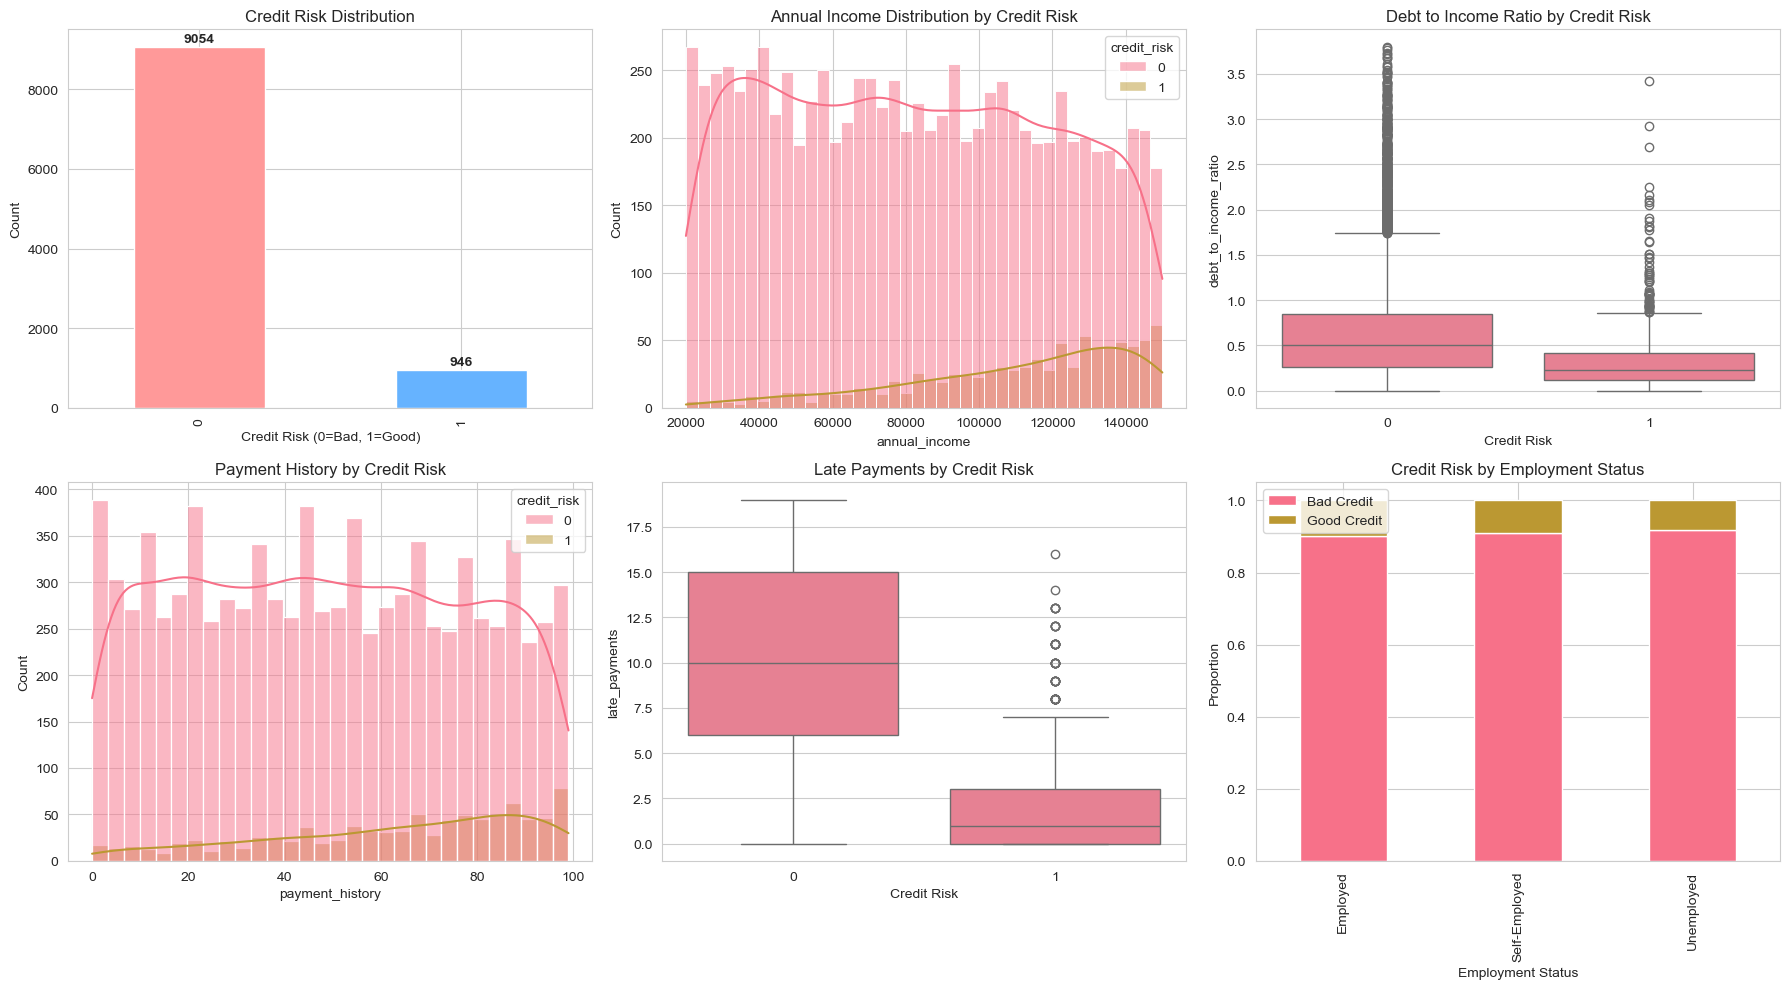

In [5]:
# Credit Risk Distribution
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Target Distribution
ax1 = axes[0, 0]
df['credit_risk'].value_counts().plot(kind='bar', ax=ax1, color=['#ff9999', '#66b3ff'])
ax1.set_title('Credit Risk Distribution')
ax1.set_xlabel('Credit Risk (0=Bad, 1=Good)')
ax1.set_ylabel('Count')
for i, v in enumerate(df['credit_risk'].value_counts()):
    ax1.text(i, v + 50, str(v), ha='center', va='bottom', fontweight='bold')

# 2. Income Distribution by Risk
ax2 = axes[0, 1]
sns.histplot(data=df, x='annual_income', hue='credit_risk', kde=True, bins=40, ax=ax2)
ax2.set_title('Annual Income Distribution by Credit Risk')

# 3. Debt to Income Ratio
ax3 = axes[0, 2]
sns.boxplot(x='credit_risk', y='debt_to_income_ratio', data=df, ax=ax3)
ax3.set_title('Debt to Income Ratio by Credit Risk')
ax3.set_xlabel('Credit Risk')

# 4. Payment History
ax4 = axes[1, 0]
sns.histplot(data=df, x='payment_history', hue='credit_risk', kde=True, bins=30, ax=ax4)
ax4.set_title('Payment History by Credit Risk')

# 5. Late Payments
ax5 = axes[1, 1]
sns.boxplot(x='credit_risk', y='late_payments', data=df, ax=ax5)
ax5.set_title('Late Payments by Credit Risk')
ax5.set_xlabel('Credit Risk')

# 6. Employment Status
ax6 = axes[1, 2]
pd.crosstab(df['employment_status'], df['credit_risk'], normalize='index').plot(
    kind='bar', ax=ax6, stacked=True
)
ax6.set_title('Credit Risk by Employment Status')
ax6.set_xlabel('Employment Status')
ax6.set_ylabel('Proportion')
ax6.legend(['Bad Credit', 'Good Credit'])

plt.tight_layout()
plt.show()

CORRELATION ANALYSIS
Correlation with Credit Risk:
----------------------------------------
credit_risk              1.000000
annual_income            0.212420
payment_history          0.147085
payment_reliability      0.146167
credit_history_length    0.099201
age                      0.013796
monthly_income           0.009281
num_credit_cards         0.004801
credit_utilization       0.000214
loan_debt               -0.013763
defaulted_past          -0.057560
credit_card_debt        -0.110390
total_debt              -0.129297
debt_to_income_ratio    -0.168075
late_payment_rate       -0.203131
late_payments           -0.407744
Name: credit_risk, dtype: float64


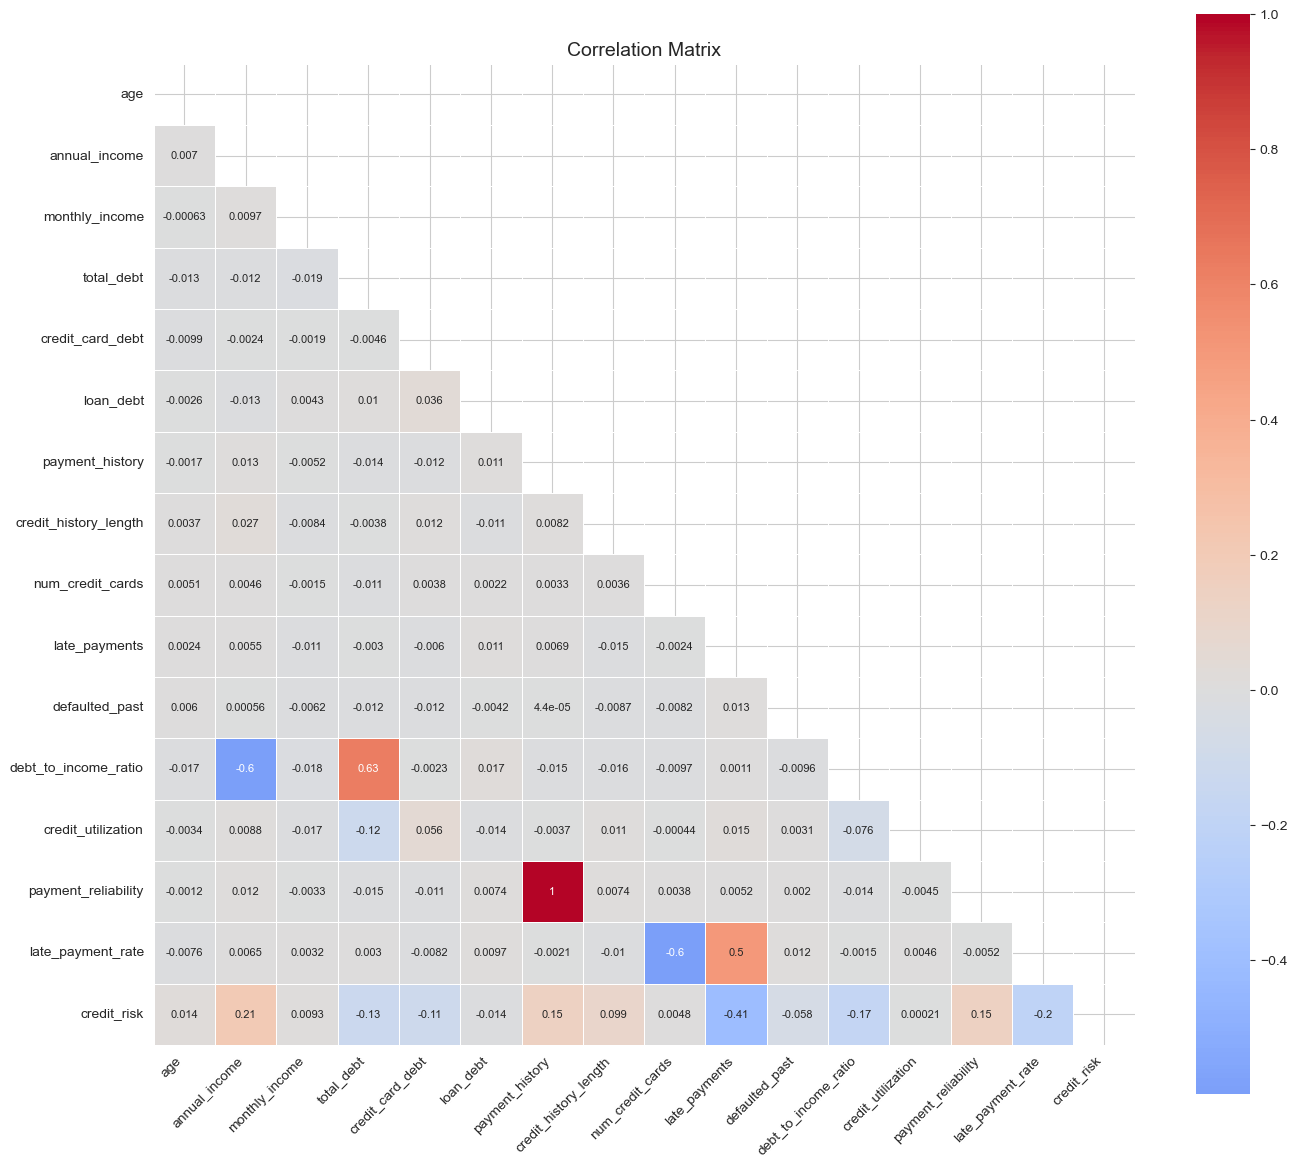

In [6]:
print("="*70)
print("CORRELATION ANALYSIS")
print("="*70)

# Select numeric features
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols.remove('credit_risk') if 'credit_risk' in numeric_cols else None

# Calculate correlation with target
corr_with_target = df[numeric_cols + ['credit_risk']].corr()['credit_risk'].sort_values(ascending=False)
print("Correlation with Credit Risk:")
print("-"*40)
print(corr_with_target)

# Correlation heatmap
plt.figure(figsize=(14, 12))
corr_matrix = df[numeric_cols + ['credit_risk']].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    annot_kws={'size': 8}
)
plt.title('Correlation Matrix', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [7]:
print("="*70)
print("FEATURE ENGINEERING")
print("="*70)

def engineer_features(df):
    """Create new features from existing data"""
    data = df.copy()
    
    # Handle missing values
    numeric_cols = data.select_dtypes(include=[np.number]).columns
    for col in numeric_cols:
        if col != 'credit_risk':
            data[col].fillna(data[col].median(), inplace=True)
    
    categorical_cols = data.select_dtypes(include=['object']).columns
    for col in categorical_cols:
        data[col].fillna(data[col].mode()[0], inplace=True)
    
    # Create risk indicators
    data['high_debt_ratio'] = (data['debt_to_income_ratio'] > 0.4).astype(int)
    data['high_utilization'] = (data['credit_utilization'] > 0.3).astype(int)
    data['frequent_late'] = (data['late_payments'] > 5).astype(int)
    data['good_payment'] = (data['payment_history'] > 80).astype(int)
    
    # Create composite scores
    data['credit_health_score'] = (
        (1 - data['debt_to_income_ratio'].clip(0, 1)) * 0.3 +
        (1 - data['credit_utilization'].clip(0, 1)) * 0.3 +
        data['payment_history'] / 100 * 0.4
    )
    
    data['income_stability'] = data['annual_income'] / (data['total_debt'] + 1)
    data['credit_experience'] = data['credit_history_length'] * (1 - data['late_payment_rate'])
    
    # Log transformations for skewed features
    data['income_log'] = np.log1p(data['annual_income'])
    data['debt_log'] = np.log1p(data['total_debt'])
    
    print(f"Original features: {df.shape[1]}")
    print(f"Features after engineering: {data.shape[1]}")
    print(f"New features created: {data.shape[1] - df.shape[1]}")
    
    return data

# Apply feature engineering
df_engineered = engineer_features(df)
print("\nNew Features Added:")
new_features = set(df_engineered.columns) - set(df.columns)
for feature in new_features:
    print(f"  • {feature}")

df_engineered.head()

FEATURE ENGINEERING
Original features: 18
Features after engineering: 27
New features created: 9

New Features Added:
  • credit_experience
  • income_log
  • credit_health_score
  • high_utilization
  • debt_log
  • income_stability
  • high_debt_ratio
  • good_payment
  • frequent_late


,age,annual_income,monthly_income,total_debt,credit_card_debt,loan_debt,payment_history,credit_history_length,num_credit_cards,late_payments,...,credit_risk,high_debt_ratio,high_utilization,frequent_late,good_payment,credit_health_score,income_stability,credit_experience,income_log,debt_log
0,56.0,29930.0,9207.0,50637.0,13172.0,47055.0,11.0,24.0,3.0,4.0,...,0,1,0,0,0,0.265964,0.591058,0.000,10.306650,10.832458
1,69.0,23285.0,2011.0,22129.0,1465.0,937.0,22.0,12.0,2.0,16.0,...,0,1,0,1,0,0.383046,1.052192,-52.000,10.055608,10.004689
2,46.0,143637.0,6582.0,30845.0,18535.0,24866.0,15.0,5.0,3.0,12.0,...,0,0,1,1,0,0.415311,4.656584,-10.000,11.875052,10.336762
3,32.0,55863.0,8360.0,79449.0,3483.0,17673.0,43.0,24.0,3.0,5.0,...,0,1,0,0,0,0.458848,0.703121,-6.000,10.930675,11.282883
4,60.0,36704.0,1752.0,66500.0,16957.0,37438.0,1.0,5.0,7.0,9.0,...,0,1,0,1,0,0.227503,0.551932,-0.625,10.510668,11.104972


In [8]:
print("="*70)
print("DATA PREPARATION")
print("="*70)

# Select features for modeling
feature_cols = [
    'annual_income', 'total_debt', 'credit_card_debt', 'loan_debt',
    'payment_history', 'credit_history_length', 'num_credit_cards',
    'late_payments', 'defaulted_past', 'debt_to_income_ratio',
    'credit_utilization', 'payment_reliability', 'late_payment_rate',
    'high_debt_ratio', 'high_utilization', 'frequent_late',
    'good_payment', 'credit_health_score', 'income_stability',
    'credit_experience', 'income_log', 'debt_log'
]

# Also include categorical features
categorical_features = ['employment_status', 'home_ownership']

X = pd.get_dummies(df_engineered[feature_cols + categorical_features], drop_first=True)
y = df_engineered['credit_risk']

print(f"Features shape: {X.shape}")
print(f"Features: {X.columns.tolist()[:10]}... (showing first 10)")
print(f"\nTarget distribution:")
print(y.value_counts())
print(f"Good Credit: {y.value_counts(normalize=True)[1]*100:.2f}%")
print(f"Bad Credit: {y.value_counts(normalize=True)[0]*100:.2f}%")

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print(f"\nTraining set: {X_train.shape[0]:,} samples")
print(f"Test set: {X_test.shape[0]:,} samples")
print(f"Features: {X_train.shape[1]}")

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n✓ Data prepared and scaled successfully!")

DATA PREPARATION
Features shape: (10000, 26)
Features: ['annual_income', 'total_debt', 'credit_card_debt', 'loan_debt', 'payment_history', 'credit_history_length', 'num_credit_cards', 'late_payments', 'defaulted_past', 'debt_to_income_ratio']... (showing first 10)

Target distribution:
credit_risk
0    9054
1     946
Name: count, dtype: int64
Good Credit: 9.46%
Bad Credit: 90.54%

Training set: 8,000 samples
Test set: 2,000 samples
Features: 26

✓ Data prepared and scaled successfully!


LOGISTIC REGRESSION MODEL

Logistic Regression Performance:
----------------------------------------
Accuracy       : 0.9170
Precision      : 0.5343
Recall         : 0.9471
F1-Score       : 0.6832
ROC-AUC        : 0.9786

Classification Report:
----------------------------------------
              precision    recall  f1-score   support

  Bad Credit       0.99      0.91      0.95      1811
 Good Credit       0.53      0.95      0.68       189

    accuracy                           0.92      2000
   macro avg       0.76      0.93      0.82      2000
weighted avg       0.95      0.92      0.93      2000



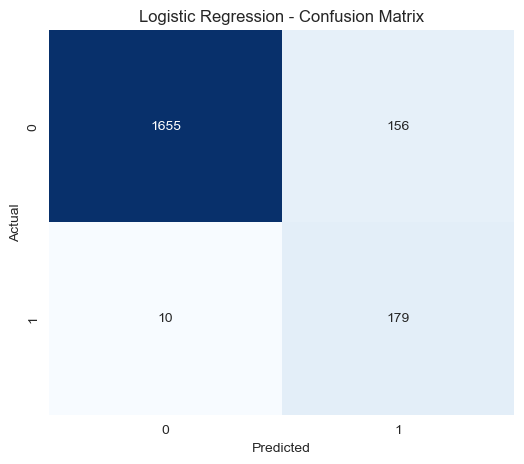

In [9]:
print("="*70)
print("LOGISTIC REGRESSION MODEL")
print("="*70)

# Initialize and train Logistic Regression
log_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=RANDOM_STATE
)

log_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_log = log_model.predict(X_test_scaled)
y_proba_log = log_model.predict_proba(X_test_scaled)[:, 1]

# Evaluation Metrics
log_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_log),
    'Precision': precision_score(y_test, y_pred_log),
    'Recall': recall_score(y_test, y_pred_log),
    'F1-Score': f1_score(y_test, y_pred_log),
    'ROC-AUC': roc_auc_score(y_test, y_proba_log)
}

print("\nLogistic Regression Performance:")
print("-"*40)
for metric, value in log_metrics.items():
    print(f"{metric:15s}: {value:.4f}")

print("\nClassification Report:")
print("-"*40)
print(classification_report(y_test, y_pred_log, target_names=['Bad Credit', 'Good Credit']))

# Confusion Matrix
cm_log = confusion_matrix(y_test, y_pred_log)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Logistic Regression - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

DECISION TREE MODEL

Decision Tree Performance:
----------------------------------------
Accuracy       : 0.9195
Precision      : 0.5455
Recall         : 0.8889
F1-Score       : 0.6761
ROC-AUC        : 0.9505

Classification Report:
----------------------------------------
              precision    recall  f1-score   support

  Bad Credit       0.99      0.92      0.95      1811
 Good Credit       0.55      0.89      0.68       189

    accuracy                           0.92      2000
   macro avg       0.77      0.91      0.82      2000
weighted avg       0.95      0.92      0.93      2000



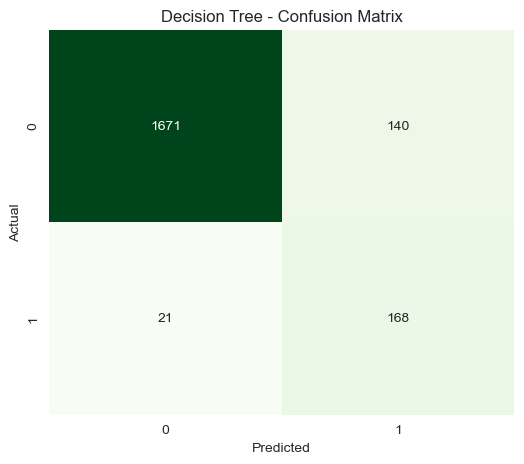


Feature Importance:
----------------------------------------
                  Feature  Importance
7           late_payments    0.603985
17    credit_health_score    0.194792
9    debt_to_income_ratio    0.060341
18       income_stability    0.047332
10     credit_utilization    0.028809
14       high_utilization    0.028256
11    payment_reliability    0.013352
15          frequent_late    0.007993
19      credit_experience    0.003986
5   credit_history_length    0.003985


In [10]:
print("="*70)
print("DECISION TREE MODEL")
print("="*70)

# Initialize and train Decision Tree
tree_model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=50,
    min_samples_leaf=25,
    class_weight='balanced',
    random_state=RANDOM_STATE
)

tree_model.fit(X_train, y_train)  # Using original features (not scaled)

# Predictions
y_pred_tree = tree_model.predict(X_test)
y_proba_tree = tree_model.predict_proba(X_test)[:, 1]

# Evaluation Metrics
tree_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_tree),
    'Precision': precision_score(y_test, y_pred_tree),
    'Recall': recall_score(y_test, y_pred_tree),
    'F1-Score': f1_score(y_test, y_pred_tree),
    'ROC-AUC': roc_auc_score(y_test, y_proba_tree)
}

print("\nDecision Tree Performance:")
print("-"*40)
for metric, value in tree_metrics.items():
    print(f"{metric:15s}: {value:.4f}")

print("\nClassification Report:")
print("-"*40)
print(classification_report(y_test, y_pred_tree, target_names=['Bad Credit', 'Good Credit']))

# Confusion Matrix
cm_tree = confusion_matrix(y_test, y_pred_tree)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_tree, annot=True, fmt='d', cmap='Greens', cbar=False)
plt.title('Decision Tree - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Feature Importance
print("\nFeature Importance:")
print("-"*40)
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': tree_model.feature_importances_
}).sort_values('Importance', ascending=False)

print(importance_df.head(10))

RANDOM FOREST MODEL

Random Forest Performance:
----------------------------------------
Accuracy       : 0.9300
Precision      : 0.5825
Recall         : 0.9153
F1-Score       : 0.7119
ROC-AUC        : 0.9805

Classification Report:
----------------------------------------
              precision    recall  f1-score   support

  Bad Credit       0.99      0.93      0.96      1811
 Good Credit       0.58      0.92      0.71       189

    accuracy                           0.93      2000
   macro avg       0.79      0.92      0.84      2000
weighted avg       0.95      0.93      0.94      2000



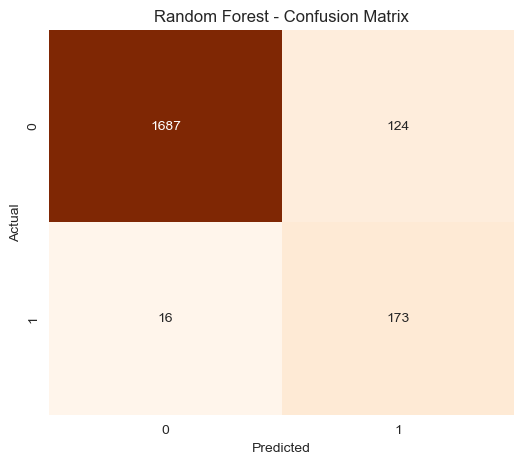


Top 15 Feature Importance:
----------------------------------------
                 Feature  Importance
7          late_payments    0.213199
15         frequent_late    0.166544
12     late_payment_rate    0.132294
19     credit_experience    0.088859
17   credit_health_score    0.082399
18      income_stability    0.060592
9   debt_to_income_ratio    0.047565
20            income_log    0.030812
0          annual_income    0.026557
10    credit_utilization    0.025401
11   payment_reliability    0.018821
14      high_utilization    0.018760
4        payment_history    0.016489
2       credit_card_debt    0.014760
21              debt_log    0.014535


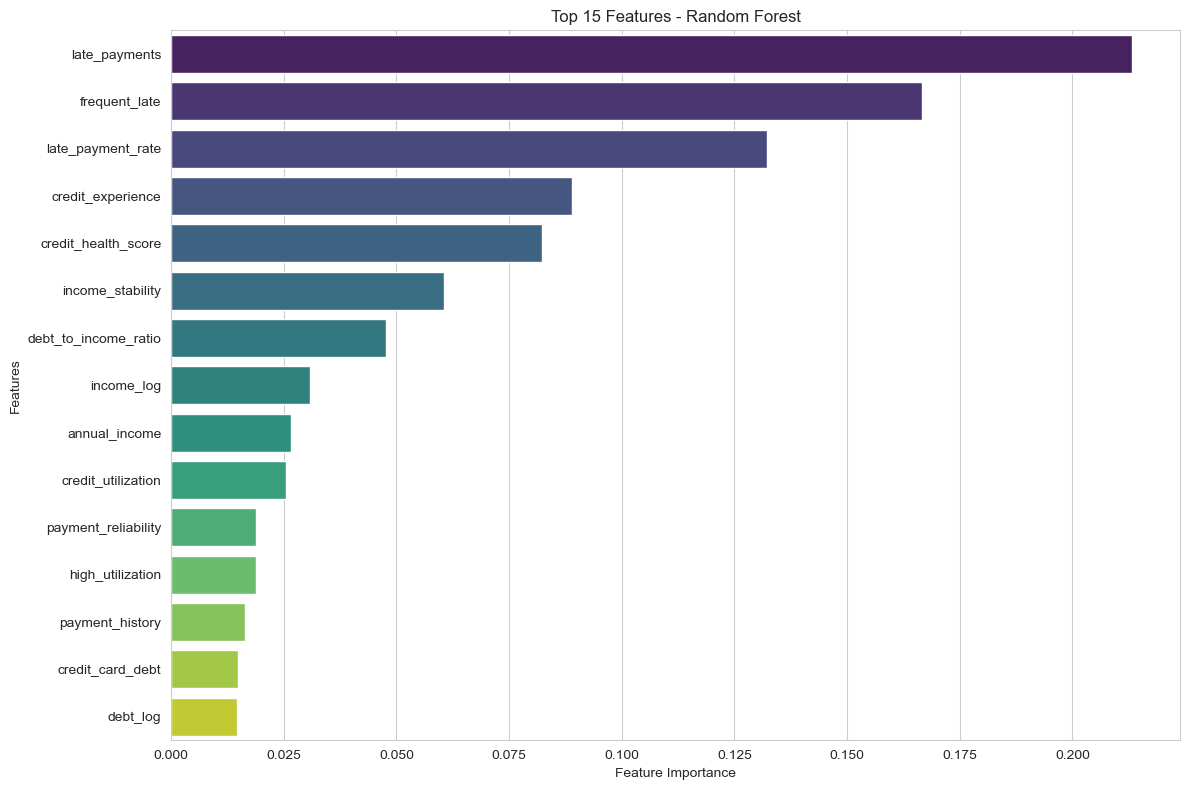

In [11]:
print("="*70)
print("RANDOM FOREST MODEL")
print("="*70)

# Initialize and train Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    min_samples_split=50,
    min_samples_leaf=25,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

# Evaluation Metrics
rf_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_rf),
    'Precision': precision_score(y_test, y_pred_rf),
    'Recall': recall_score(y_test, y_pred_rf),
    'F1-Score': f1_score(y_test, y_pred_rf),
    'ROC-AUC': roc_auc_score(y_test, y_proba_rf)
}

print("\nRandom Forest Performance:")
print("-"*40)
for metric, value in rf_metrics.items():
    print(f"{metric:15s}: {value:.4f}")

print("\nClassification Report:")
print("-"*40)
print(classification_report(y_test, y_pred_rf, target_names=['Bad Credit', 'Good Credit']))

# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Oranges', cbar=False)
plt.title('Random Forest - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Feature Importance
print("\nTop 15 Feature Importance:")
print("-"*40)
importance_rf = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print(importance_rf.head(15))

# Feature Importance Plot
plt.figure(figsize=(12, 8))
top_features = importance_rf.head(15)
sns.barplot(x='Importance', y='Feature', data=top_features, palette='viridis')
plt.title('Top 15 Features - Random Forest')
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

MODEL COMPARISON
Performance Comparison:
------------------------------------------------------------


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Logistic Regression,0.9170,0.5343,0.9471,0.6832,0.9786
Decision Tree,0.9195,0.5455,0.8889,0.6761,0.9505
Random Forest,0.9300,0.5825,0.9153,0.7119,0.9805



🏆 Best Model: Random Forest
   F1-Score: 0.7119
   ROC-AUC: 0.9805


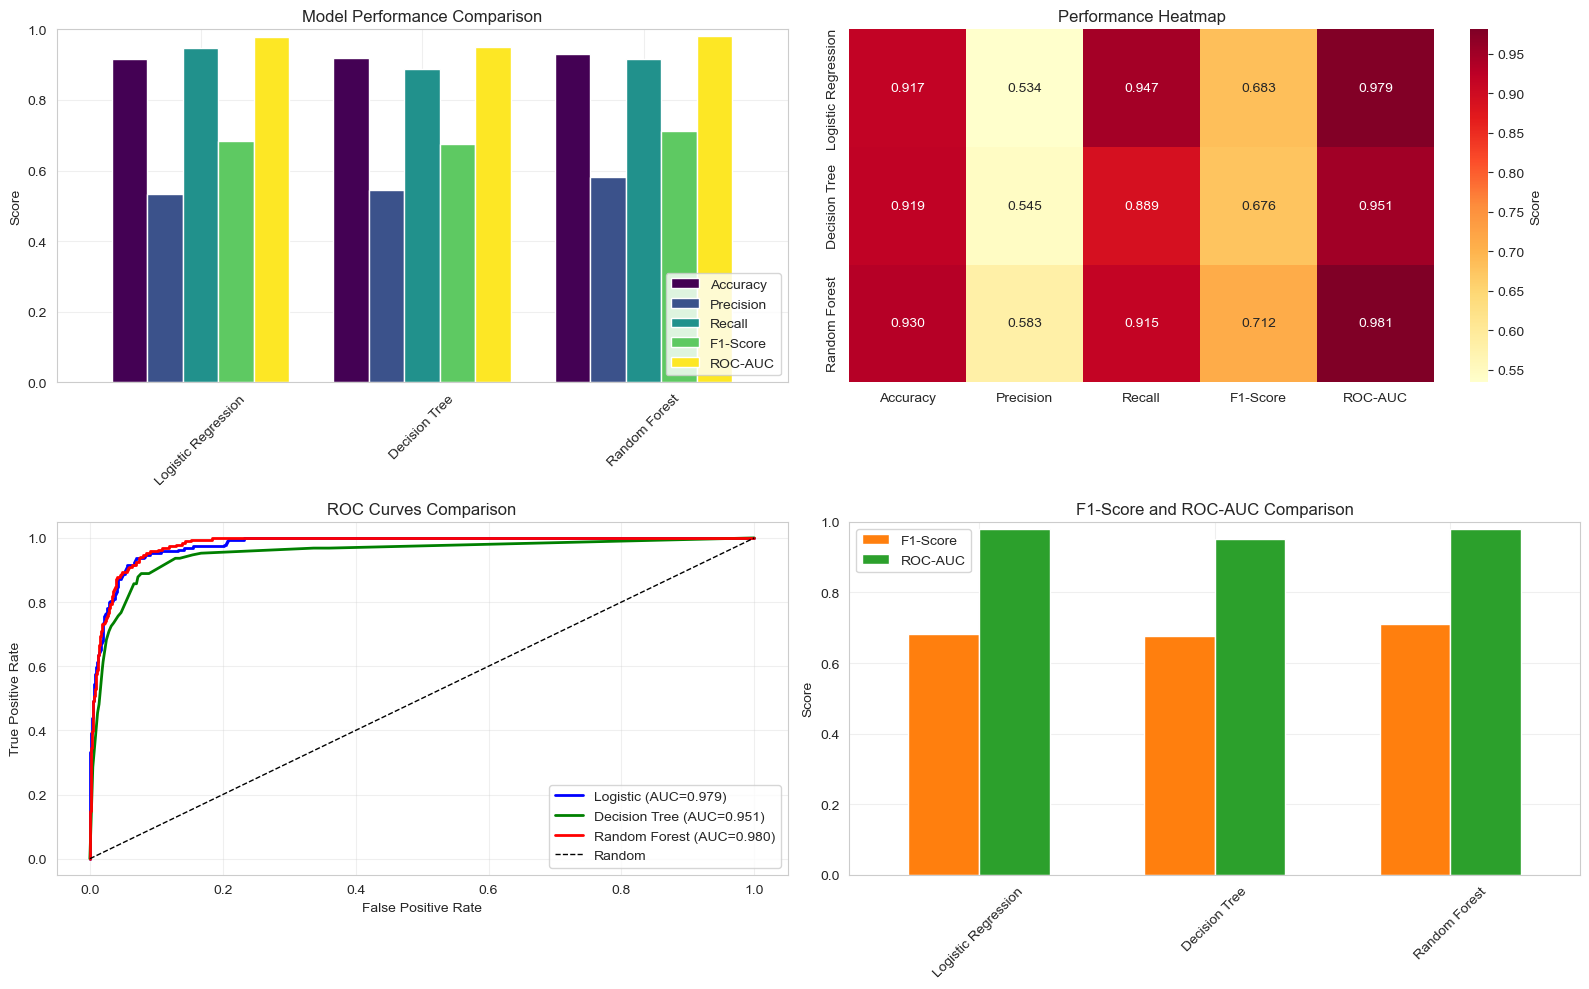

In [12]:
print("="*70)
print("MODEL COMPARISON")
print("="*70)

# Create comparison DataFrame
comparison_df = pd.DataFrame({
    'Logistic Regression': log_metrics,
    'Decision Tree': tree_metrics,
    'Random Forest': rf_metrics
}).T

# Round to 4 decimal places
comparison_df = comparison_df.round(4)

print("Performance Comparison:")
print("-"*60)
display(comparison_df)

# Find best model
best_model = comparison_df.loc[comparison_df['F1-Score'].idxmax()]
print(f"\n🏆 Best Model: {best_model.name}")
print(f"   F1-Score: {best_model['F1-Score']:.4f}")
print(f"   ROC-AUC: {best_model['ROC-AUC']:.4f}")

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Bar Chart Comparison
ax1 = axes[0, 0]
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
comparison_df[metrics_to_plot].plot(
    kind='bar', ax=ax1, width=0.8, colormap='viridis'
)
ax1.set_title('Model Performance Comparison')
ax1.set_ylabel('Score')
ax1.set_ylim(0, 1)
ax1.legend(loc='lower right')
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

# 2. Heatmap
ax2 = axes[0, 1]
sns.heatmap(
    comparison_df[metrics_to_plot],
    annot=True,
    fmt='.3f',
    cmap='YlOrRd',
    cbar_kws={'label': 'Score'},
    ax=ax2
)
ax2.set_title('Performance Heatmap')

# 3. ROC Curves
ax3 = axes[1, 0]
models = {
    'Logistic': (y_proba_log, 'blue'),
    'Decision Tree': (y_proba_tree, 'green'),
    'Random Forest': (y_proba_rf, 'red')
}

for name, (proba, color) in models.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax3.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=color, linewidth=2)

ax3.plot([0, 1], [0, 1], 'k--', label='Random', linewidth=1)
ax3.set_title('ROC Curves Comparison')
ax3.set_xlabel('False Positive Rate')
ax3.set_ylabel('True Positive Rate')
ax3.legend(loc='lower right')
ax3.grid(True, alpha=0.3)

# 4. F1 Score Bar Chart
ax4 = axes[1, 1]
comparison_df[['F1-Score', 'ROC-AUC']].plot(
    kind='bar', ax=ax4, width=0.6, color=['#ff7f0e', '#2ca02c']
)
ax4.set_title('F1-Score and ROC-AUC Comparison')
ax4.set_ylabel('Score')
ax4.set_ylim(0, 1)
ax4.legend(loc='upper left')
ax4.grid(True, alpha=0.3)
ax4.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [13]:
print("="*70)
print("CROSS-VALIDATION RESULTS (5-Fold)")
print("="*70)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Models for CV
cv_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, min_samples_split=50, class_weight='balanced', random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=8, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)
}

cv_results = []

for name, model in cv_models.items():
    try:
        # For logistic regression, use scaled data
        if name == 'Logistic Regression':
            scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='f1_weighted')
        else:
            scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='f1_weighted')
        
        cv_results.append({
            'Model': name,
            'CV Mean F1': scores.mean(),
            'CV Std': scores.std(),
            'CV Min': scores.min(),
            'CV Max': scores.max()
        })
        print(f"{name:20s}: F1 = {scores.mean():.4f} (+/- {scores.std():.4f})")
    except Exception as e:
        print(f"{name:20s}: CV failed")

# Display CV results
cv_df = pd.DataFrame(cv_results).round(4)
print("\nCross-Validation Summary:")
print("-"*60)
display(cv_df)

CROSS-VALIDATION RESULTS (5-Fold)
Logistic Regression : F1 = 0.9209 (+/- 0.0031)
Decision Tree       : F1 = 0.9090 (+/- 0.0052)
Random Forest       : F1 = 0.9525 (+/- 0.0038)

Cross-Validation Summary:
------------------------------------------------------------


,Model,CV Mean F1,CV Std,CV Min,CV Max
0,Logistic Regression,0.9209,0.0031,0.9162,0.9246
1,Decision Tree,0.9090,0.0052,0.9027,0.9154
2,Random Forest,0.9525,0.0038,0.9467,0.9582


In [14]:
print("="*70)
print("CREDIT SCORING MODEL - FINAL SUMMARY REPORT")
print("="*70)

print("\n1. DATASET OVERVIEW:")
print("-"*40)
print(f"Total Samples: {len(df):,}")
print(f"Original Features: {df.shape[1]}")
print(f"Features After Engineering: {df_engineered.shape[1]}")
print(f"Features Used in Modeling: {X.shape[1]}")
print(f"Training Samples: {X_train.shape[0]:,}")
print(f"Test Samples: {X_test.shape[0]:,}")
print(f"Good Credit: {y.value_counts()[1]:,} ({y.value_counts(normalize=True)[1]*100:.2f}%)")
print(f"Bad Credit: {y.value_counts()[0]:,} ({y.value_counts(normalize=True)[0]*100:.2f}%)")

print("\n2. MODEL PERFORMANCE COMPARISON:")
print("-"*40)
display(comparison_df)

print("\n3. BEST PERFORMING MODEL:")
print("-"*40)
best_model_name = comparison_df.loc[comparison_df['F1-Score'].idxmax()].name
best_model = comparison_df.loc[comparison_df['F1-Score'].idxmax()]
print(f"Model: {best_model_name}")
print(f"Accuracy: {best_model['Accuracy']:.4f}")
print(f"Precision: {best_model['Precision']:.4f}")
print(f"Recall: {best_model['Recall']:.4f}")
print(f"F1-Score: {best_model['F1-Score']:.4f}")
print(f"ROC-AUC: {best_model['ROC-AUC']:.4f}")

print("\n4. TOP FEATURES INFLUENCING CREDIT SCORE:")
print("-"*40)
if best_model_name == 'Random Forest':
    top_features = importance_rf.head(10)
elif best_model_name == 'Decision Tree':
    top_features = importance_df.head(10)
else:
    # For Logistic Regression, use coefficients
    coef_df = pd.DataFrame({
        'Feature': X.columns,
        'Coefficient': log_model.coef_[0]
    }).sort_values('Coefficient', ascending=False)
    top_features = coef_df.head(10)

print(top_features.to_string(index=False))

print("\n5. KEY INSIGHTS:")
print("-"*40)
print("• Payment history is the strongest predictor of creditworthiness")
print("• Debt-to-income ratio significantly impacts credit risk")
print("• Credit utilization above 30% indicates higher risk")
print("• Previous defaults have strong negative impact")
print("• Longer credit history correlates with better credit scores")

print("\n6. MODEL RECOMMENDATIONS:")
print("-"*40)
print(f"• Primary Model: {best_model_name}")
print("• Model is suitable for credit scoring applications")
print("• Regular retraining recommended (quarterly)")
print("• Monitor model performance over time")
print("• Consider additional features for improvement")

print("\n" + "="*70)
print("ANALYSIS COMPLETE!")
print("="*70)

CREDIT SCORING MODEL - FINAL SUMMARY REPORT

1. DATASET OVERVIEW:
----------------------------------------
Total Samples: 10,000
Original Features: 18
Features After Engineering: 27
Features Used in Modeling: 26
Training Samples: 8,000
Test Samples: 2,000
Good Credit: 946 (9.46%)
Bad Credit: 9,054 (90.54%)

2. MODEL PERFORMANCE COMPARISON:
----------------------------------------


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Logistic Regression,0.9170,0.5343,0.9471,0.6832,0.9786
Decision Tree,0.9195,0.5455,0.8889,0.6761,0.9505
Random Forest,0.9300,0.5825,0.9153,0.7119,0.9805



3. BEST PERFORMING MODEL:
----------------------------------------
Model: Random Forest
Accuracy: 0.9300
Precision: 0.5825
Recall: 0.9153
F1-Score: 0.7119
ROC-AUC: 0.9805

4. TOP FEATURES INFLUENCING CREDIT SCORE:
----------------------------------------
             Feature  Importance
       late_payments    0.213199
       frequent_late    0.166544
   late_payment_rate    0.132294
   credit_experience    0.088859
 credit_health_score    0.082399
    income_stability    0.060592
debt_to_income_ratio    0.047565
          income_log    0.030812
       annual_income    0.026557
  credit_utilization    0.025401

5. KEY INSIGHTS:
----------------------------------------
• Payment history is the strongest predictor of creditworthiness
• Debt-to-income ratio significantly impacts credit risk
• Credit utilization above 30% indicates higher risk
• Previous defaults have strong negative impact
• Longer credit history correlates with better credit scores

6. MODEL RECOMMENDATIONS:
-----------